In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt   

Yearly average TB1 (EUR/MWh):
Year
2022    126.42
2023     62.42
2024     61.60
2025     79.38
2026     52.91
Name: TB1, dtype: float64


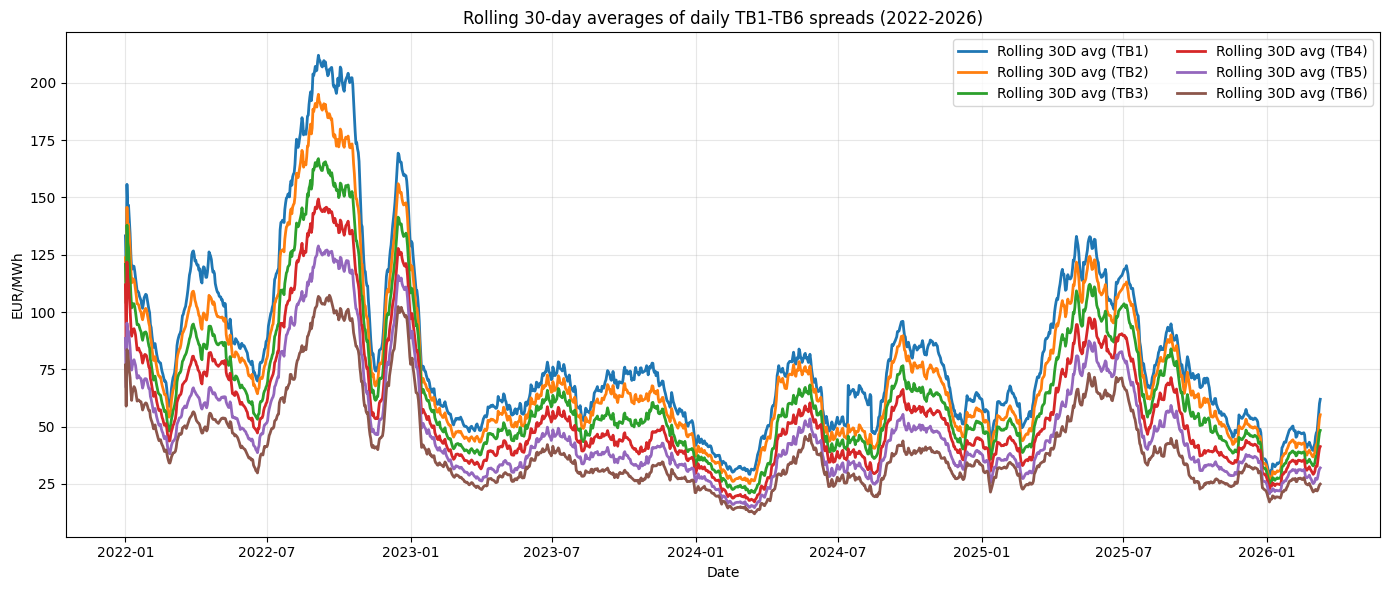

In [18]:
from pathlib import Path
# --- load all spot-market CSV files (supports both wide and long formats) ---
data_dir = Path("auction_spot_prices")
csv_files = sorted(data_dir.glob("auction_spot_prices_switzerland_*.csv"))
if not csv_files:
    raise FileNotFoundError("No matching auction_spot_prices_switzerland_*.csv files found.")

# --- plot switches ---
INCLUDE_DAILY_TB = False   # True: plot daily TB lines + rolling averages; False: rolling averages only

def tb_spreads(values):
    vals = np.sort(values[~np.isnan(values)])
    out = []
    for k in range(1, 7):
        if len(vals) >= 2 * k:
            out.append(vals[-k] - vals[k - 1])
        else:
            out.append(np.nan)
    return out
tb_frames = []
for f in csv_files:
    d = pd.read_csv(f, comment="#")
    # Format A (2023+): one row per day with Hour columns
    if "Delivery day" in d.columns:
        d["Delivery day"] = pd.to_datetime(d["Delivery day"], dayfirst=True, errors="coerce")
        hour_cols = [c for c in d.columns if c.startswith("Hour")]
        d[hour_cols] = d[hour_cols].apply(pd.to_numeric, errors="coerce")
        tb_vals = d[hour_cols].apply(lambda r: tb_spreads(r.to_numpy(dtype=float)), axis=1, result_type="expand")
        tb_vals.columns = ["TB1", "TB2", "TB3", "TB4", "TB5", "TB6"]
        t = pd.concat([d[["Delivery day"]], tb_vals], axis=1)
        t = t.dropna(subset=["Delivery day"])
        tb_frames.append(t)
    # Format B (2022): one row per hour with MTU + Price
    elif "MTU (CET/CEST)" in d.columns and "Price" in d.columns:
        d["Price"] = pd.to_numeric(d["Price"], errors="coerce")
        # Extract start date from strings like '01/01/2022 00:00 - 01/01/2022 01:00'
        d["Delivery day"] = pd.to_datetime(
            d["MTU (CET/CEST)"].astype(str).str.extract(r"(\d{2}/\d{2}/\d{4})")[0],
            dayfirst=True,
            errors="coerce",
        )
        d2 = d.dropna(subset=["Delivery day", "Price"]).copy()
        g = d2.groupby("Delivery day")["Price"].apply(
            lambda s: pd.Series(tb_spreads(s.to_numpy(dtype=float)), index=["TB1", "TB2", "TB3", "TB4", "TB5", "TB6"])
        )
        t = g.unstack().reset_index()
        tb_frames.append(t)
if not tb_frames:
    raise ValueError("No supported CSV format found in the selected files.")
df = pd.concat(tb_frames, ignore_index=True)
df = df.dropna(subset=["Delivery day"]).sort_values("Delivery day")

# If overlapping dates exist across files, keep one row per day
df = df.groupby("Delivery day", as_index=False)[["TB1", "TB2", "TB3", "TB4", "TB5", "TB6"]].mean()
yearly_average_tb1 = df.assign(Year=df["Delivery day"].dt.year).groupby("Year")["TB1"].mean()
print("Yearly average TB1 (EUR/MWh):")
print(yearly_average_tb1.round(2))
# --- rolling 30-day averages ---
tb_cols = ["TB1", "TB2", "TB3", "TB4", "TB5", "TB6"]
for col in tb_cols:
    df[f"{col}_rolling_30d"] = df[col].rolling(window=30, min_periods=1).mean()
# --- plot (daily TB1..TB6 + rolling 30d averages) ---
year_min = int(df["Delivery day"].dt.year.min())
year_max = int(df["Delivery day"].dt.year.max())
plt.figure(figsize=(14, 6))
if INCLUDE_DAILY_TB:
    for col in tb_cols:
        plt.plot(df["Delivery day"], df[col], label=f"Daily {col}", alpha=0.35)
for col in tb_cols:
    plt.plot(df["Delivery day"], df[f"{col}_rolling_30d"], label=f"Rolling 30D avg ({col})", linewidth=2)
plt.title(f"Rolling 30-day averages of daily TB1-TB6 spreads ({year_min}-{year_max})")
plt.xlabel("Date")
plt.ylabel("EUR/MWh")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [19]:
#battery input parameters
capacity = 0.215 #MWh
c_rate = 0.5
round_trip_efficiency = 0.90
power = capacity * c_rate
max_daily_cycles = 2

#finance parameters
specific_hardware_cost = 242 # range: 242-231
spefific_installation_cost = 141 #range: 141-106
cost = (specific_hardware_cost + spefific_installation_cost) * capacity * 1000
Interest_rate = 0.05

def calculate_daily_revenue(
    df_input,
    power,
    max_daily_cycles,
    round_trip_efficiency=1.0,
    year=None,
    average_spread=None,
):
    tb_count_used = min(int(max_daily_cycles * 2), 6)
    tb_cols_used = [f"TB{i}" for i in range(1, tb_count_used + 1)]
    revenue_df = df_input.copy()

    if year is not None:
        revenue_df = revenue_df[revenue_df["Delivery day"].dt.year == year].copy()

    scaled_tb = revenue_df[tb_cols_used].copy()
    historical_average_spread = revenue_df["TB1"].mean()

    if average_spread is not None:
        if pd.isna(historical_average_spread) or historical_average_spread == 0:
            raise ValueError("Historical average spread is zero or NaN, so scaling is not possible.")
        spread_scale_factor = average_spread / historical_average_spread
        scaled_tb = scaled_tb * spread_scale_factor

    revenue = scaled_tb.sum(axis=1) * power * round_trip_efficiency
    return pd.DataFrame({
        "Delivery day": revenue_df["Delivery day"],
        "daily_revenue_eur": revenue,
        "daily_revenue_rolling_30d": revenue.rolling(window=30, min_periods=1).mean(),
        "historical_average_spread": historical_average_spread,
        "applied_average_spread": average_spread if average_spread is not None else historical_average_spread,
    }), tb_cols_used

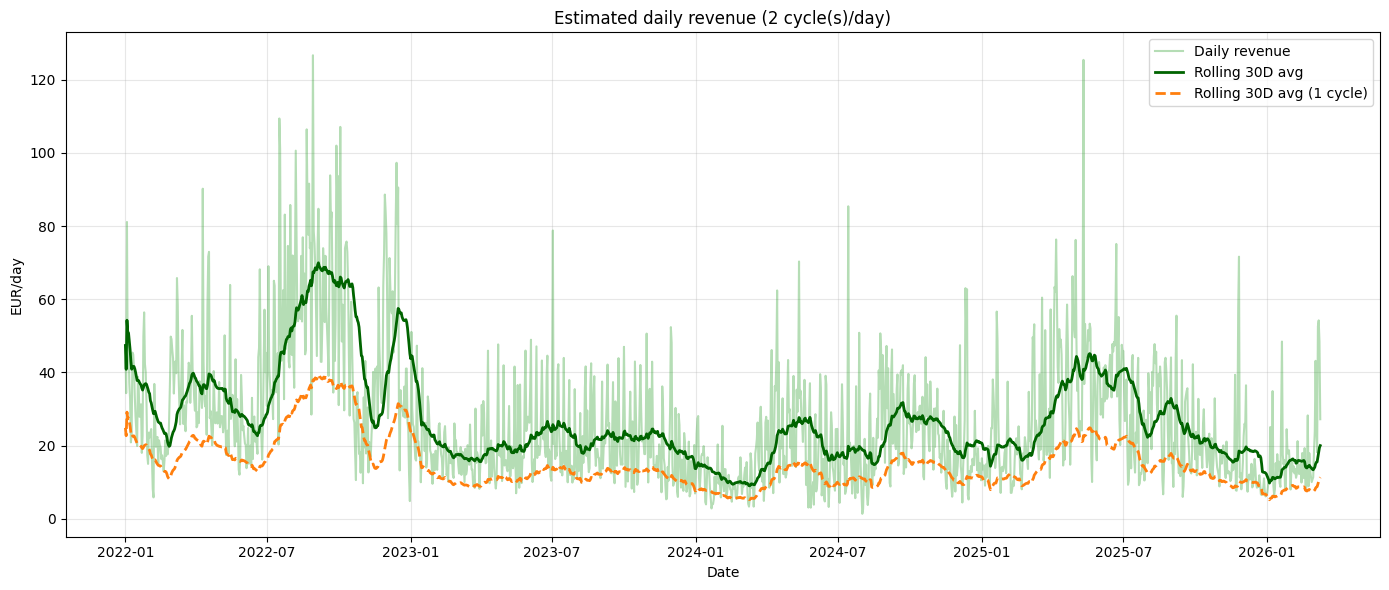

In [4]:
# --- daily revenue plot based on selected number of daily cycles ---
revenue_df, tb_cols_used = calculate_daily_revenue(
    df,
    power=power,
    max_daily_cycles=2,
    round_trip_efficiency=round_trip_efficiency, 
    year= None,
    average_spread=None,
)
single_cycle_revenue_df, _ = calculate_daily_revenue(
    df,
    power=power,
    max_daily_cycles=1,
    round_trip_efficiency=round_trip_efficiency,
)
df["daily_revenue_eur"] = revenue_df["daily_revenue_eur"]
df["daily_revenue_rolling_30d"] = revenue_df["daily_revenue_rolling_30d"]
df["single_cycle_revenue_rolling_30d"] = single_cycle_revenue_df["daily_revenue_rolling_30d"]

plt.figure(figsize=(14, 6))
plt.plot(df["Delivery day"], df["daily_revenue_eur"], label="Daily revenue", color="tab:green", alpha=0.35)
plt.plot(df["Delivery day"], df["daily_revenue_rolling_30d"], label="Rolling 30D avg", color="darkgreen", linewidth=2)
plt.plot(df["Delivery day"], df["single_cycle_revenue_rolling_30d"], label="Rolling 30D avg (1 cycle)", color="tab:orange", linewidth=2, linestyle="--")
plt.title(f"Estimated daily revenue ({max_daily_cycles} cycle(s)/day)")
plt.xlabel("Date")
plt.ylabel("EUR/day")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Projection year repeated: 2025
Annual revenue used: 9,629.88 EUR/year
Investment cost: 82,345.00 EUR
Discount rate: 5.00%


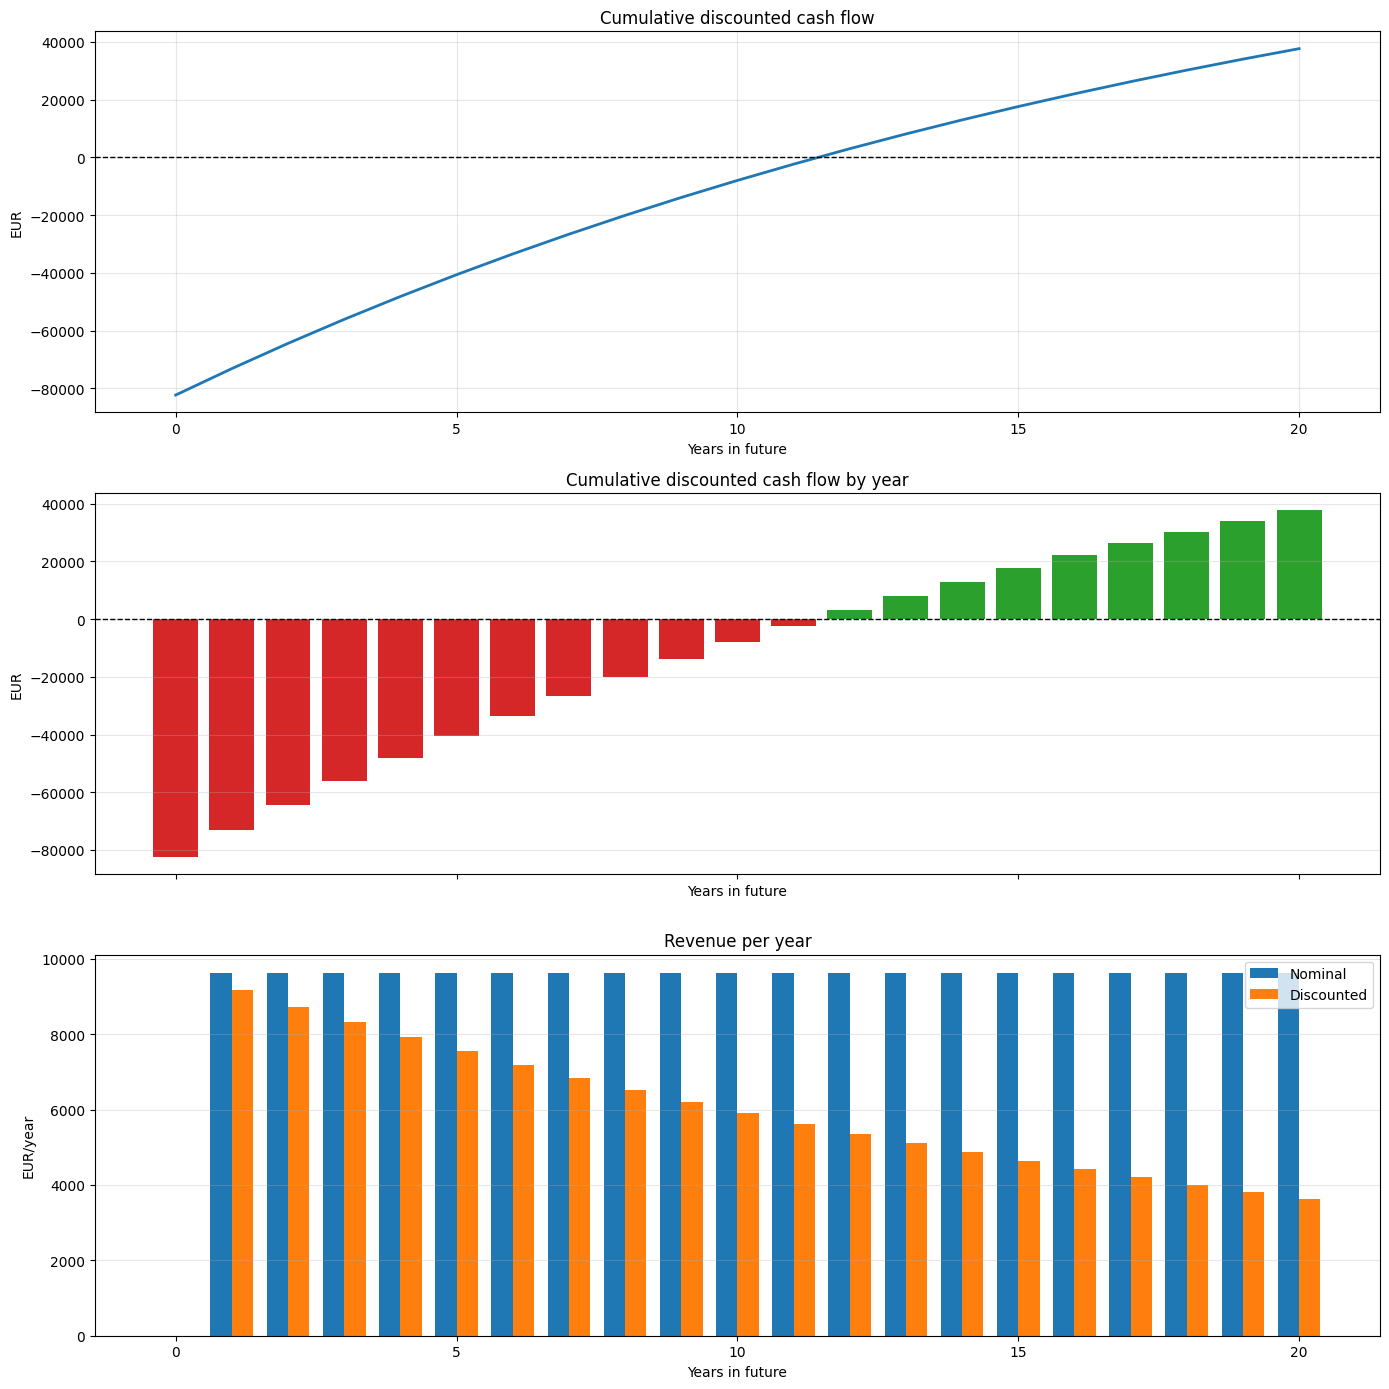

In [15]:
# --- future cumulative cash flow projection ---
projection_year = 2025
projection_horizon_years = 20
projection_average_spread = None

projection_revenue_df, _ = calculate_daily_revenue(
    df,
    power=power,
    max_daily_cycles=2,
    round_trip_efficiency=round_trip_efficiency,
    year=projection_year,
    average_spread=projection_average_spread,
)

annual_revenue_eur = projection_revenue_df["daily_revenue_eur"].sum()
projection_years = np.arange(0, projection_horizon_years + 1)
discounted_cash_flows = np.zeros_like(projection_years, dtype=float)
discounted_cash_flows[1:] = annual_revenue_eur / (1 + Interest_rate) ** projection_years[1:]
cumulative_discounted_cash_flow = -cost + np.cumsum(discounted_cash_flows)

cash_flow_projection_df = pd.DataFrame({
    "Years in future": projection_years,
    "Cumulative discounted cash flow (EUR)": cumulative_discounted_cash_flow,
})

print(f"Projection year repeated: {projection_year}")
print(f"Annual revenue used: {annual_revenue_eur:,.2f} EUR/year")
print(f"Investment cost: {cost:,.2f} EUR")
print(f"Discount rate: {Interest_rate:.2%}")

annual_revenue_projection = np.zeros_like(projection_years, dtype=float)
annual_revenue_projection[1:] = annual_revenue_eur
discounted_revenue_projection = discounted_cash_flows.copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

axes[0].plot(
    cash_flow_projection_df["Years in future"],
    cash_flow_projection_df["Cumulative discounted cash flow (EUR)"],
    color="tab:blue",
    linewidth=2,
)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Cumulative discounted cash flow")
axes[0].set_xlabel("Years in future")
axes[0].set_ylabel("EUR")
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis="x", labelbottom=True)

bar_colors = ["tab:red" if value < 0 else "tab:green" for value in cash_flow_projection_df["Cumulative discounted cash flow (EUR)"]]
axes[1].bar(
    cash_flow_projection_df["Years in future"],
    cash_flow_projection_df["Cumulative discounted cash flow (EUR)"],
    color=bar_colors,
    width=0.8,
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Cumulative discounted cash flow by year")
axes[1].set_xlabel("Years in future")
axes[1].set_ylabel("EUR")
axes[1].grid(True, axis="y", alpha=0.3)

bar_width = 0.38
axes[2].bar(
    projection_years - bar_width / 2,
    annual_revenue_projection,
    color="tab:blue",
    width=bar_width,
    label="Nominal",
)
axes[2].bar(
    projection_years + bar_width / 2,
    discounted_revenue_projection,
    color="tab:orange",
    width=bar_width,
    label="Discounted",
)
axes[2].set_title("Revenue per year")
axes[2].set_xlabel("Years in future")
axes[2].set_ylabel("EUR/year")
axes[2].grid(True, axis="y", alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

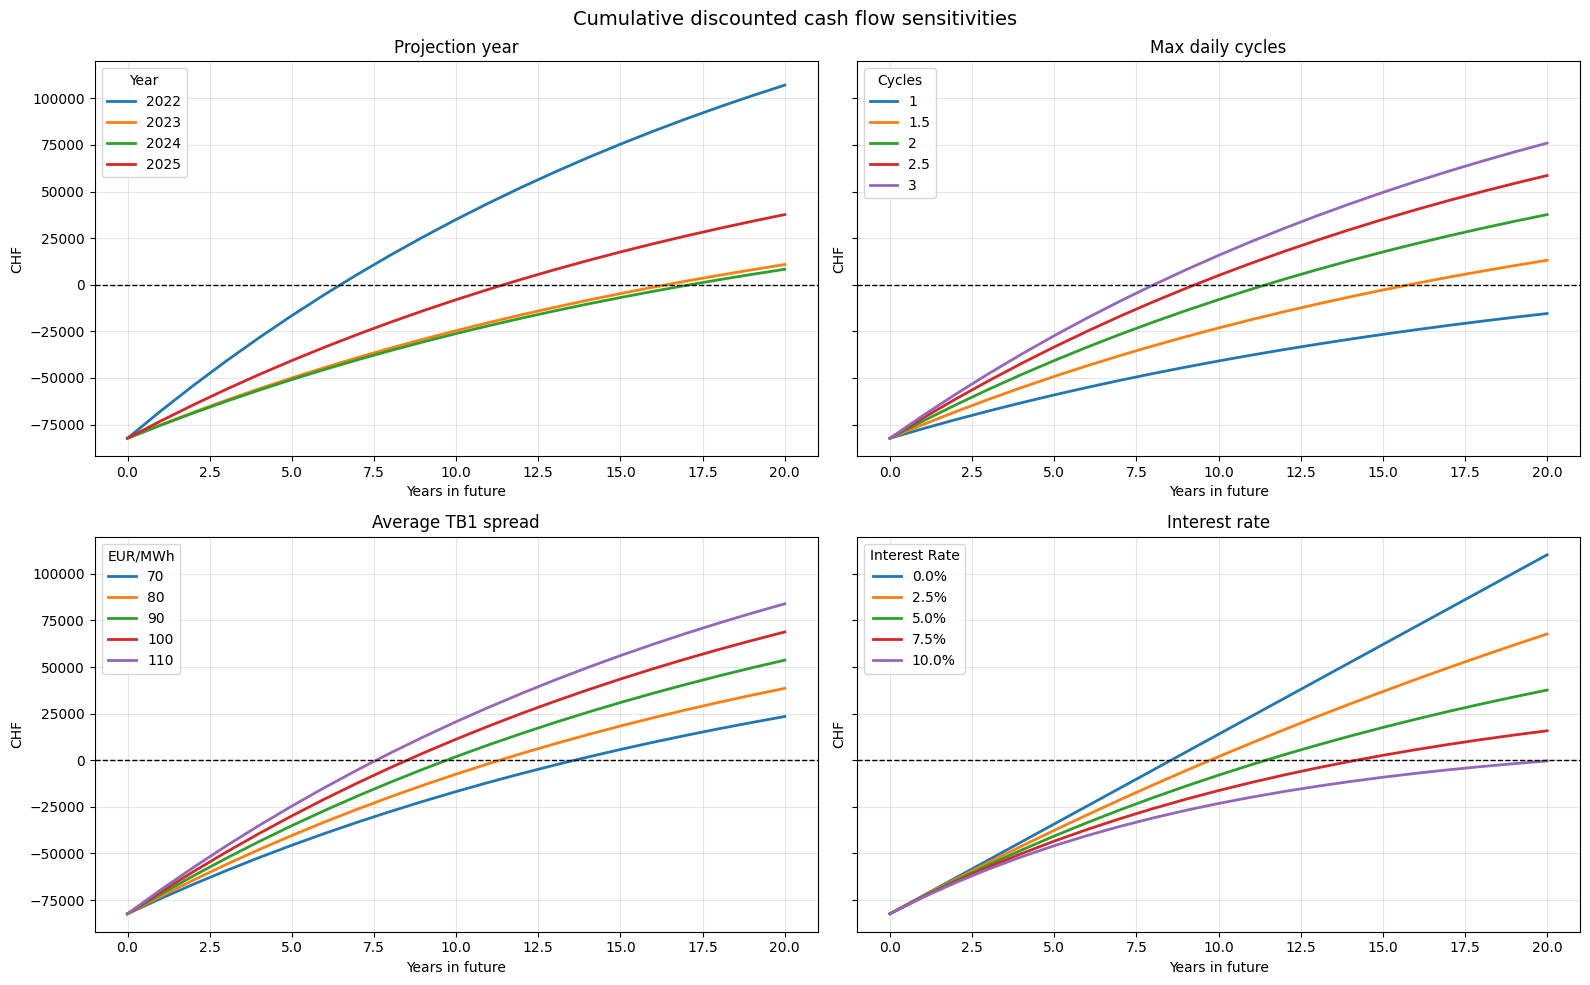

In [14]:
# --- sensitivity plots for cumulative discounted cash flow ---
default_projection_year = 2025
default_max_daily_cycles = 2
default_average_spread = None
default_interest_rate = 0.05
projection_horizon_years = 20

def build_cash_flow_curve(projection_year, max_daily_cycles, average_spread, interest_rate):
    revenue_df, _ = calculate_daily_revenue(
        df,
        power=power,
        max_daily_cycles=max_daily_cycles,
        round_trip_efficiency=round_trip_efficiency,
        year=projection_year,
        average_spread=average_spread,
    )
    annual_revenue_eur = revenue_df["daily_revenue_eur"].sum()
    years = np.arange(0, projection_horizon_years + 1)
    discounted_cash_flows = np.zeros_like(years, dtype=float)
    discounted_cash_flows[1:] = annual_revenue_eur / (1 + interest_rate) ** years[1:]
    cumulative_discounted_cash_flow = -cost + np.cumsum(discounted_cash_flows)
    return years, cumulative_discounted_cash_flow

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.ravel()

# Plot 1: projection year
for projection_year in [2022, 2023, 2024, 2025]:
    years, curve = build_cash_flow_curve(
        projection_year=projection_year,
        max_daily_cycles=default_max_daily_cycles,
        average_spread=default_average_spread,
        interest_rate=default_interest_rate,
    )
    axes[0].plot(years, curve, label=str(projection_year), linewidth=2)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Projection year")
axes[0].set_xlabel("Years in future")
axes[0].set_ylabel("CHF")
axes[0].tick_params(axis="x", labelbottom=True)
axes[0].legend(title="Year")
axes[0].grid(True, alpha=0.3)

# Plot 2: max daily cycles
for max_daily_cycles_scenario in [1, 1.5, 2, 2.5, 3]:
    years, curve = build_cash_flow_curve(
        projection_year=default_projection_year,
        max_daily_cycles=max_daily_cycles_scenario,
        average_spread=default_average_spread,
        interest_rate=default_interest_rate,
    )
    axes[1].plot(years, curve, label=str(max_daily_cycles_scenario), linewidth=2)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Max daily cycles")
axes[1].set_xlabel("Years in future")
axes[1].set_ylabel("CHF")
axes[1].tick_params(axis="x", labelbottom=True)
axes[1].legend(title="Cycles")
axes[1].grid(True, alpha=0.3)

# Plot 3: average spread
for average_spread_scenario in [70, 80, 90, 100, 110]:
    years, curve = build_cash_flow_curve(
        projection_year=default_projection_year,
        max_daily_cycles=default_max_daily_cycles,
        average_spread=average_spread_scenario,
        interest_rate=default_interest_rate,
    )
    axes[2].plot(years, curve, label=str(average_spread_scenario), linewidth=2)
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Average TB1 spread")
axes[2].set_xlabel("Years in future")
axes[2].set_ylabel("CHF")
axes[2].legend(title="EUR/MWh")
axes[2].grid(True, alpha=0.3)

# Plot 4: interest rate
for interest_rate_scenario in [0, 0.025, 0.05, 0.075, 0.1]:
    years, curve = build_cash_flow_curve(
        projection_year=default_projection_year,
        max_daily_cycles=default_max_daily_cycles,
        average_spread=default_average_spread,
        interest_rate=interest_rate_scenario,
    )
    axes[3].plot(years, curve, label=f"{interest_rate_scenario:.1%}", linewidth=2)
axes[3].axhline(0, color="black", linestyle="--", linewidth=1)
axes[3].set_title("Interest rate")
axes[3].set_xlabel("Years in future")
axes[3].set_ylabel("CHF")
axes[3].legend(title="Interest Rate")
axes[3].grid(True, alpha=0.3)

fig.suptitle("Cumulative discounted cash flow sensitivities", fontsize=14)
plt.tight_layout()
plt.show()